## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [224]:
# to load and manipulate data
import pandas as pd
import numpy as np

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# to split data into training and test sets
from sklearn.model_selection import train_test_split

# to build decision tree model
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# to tune different models
from sklearn.model_selection import GridSearchCV

# to compute classification metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
)

import warnings
warnings.filterwarnings("ignore")

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

## Loading the dataset

In [225]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [226]:
# loading data into a pandas dataframe
loan_modelling = pd.read_csv("/content/drive/MyDrive/AIML/Loan_Modelling.csv")

In [227]:
# creating a copy of the data
data = loan_modelling.copy()

## Data Overview

### Viewing the first and last 5 rows of the dataset

In [228]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [229]:
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


* Observations
* Sanity checks

### Checking the shape of the dataset.

In [230]:
data.shape

(5000, 14)

- The dataset has 5000 rows and 14 columns.

### Checking the attribute types

In [231]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


- There are no null values or object in the data
- There are all numerical values

### Checking the statistical summary

In [232]:
data.describe(include="all")

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


- Average customer age is **45**, with a broad spread (std ≈ 11.5), indicating a mix of younger and older adults.
- Experience averages **20 years**, but the minimum is **–3**, a clear data error that needs correction.
- Income averages $73.8k, with a very wide range ($8k–$224k) and high variability (std ≈ 46), meaning income differences across customers are substantial.
- Most customers have small families: median **2**, with the full range **1–4**.
- Education level centers around **2** (likely "graduate"), with values from **1 to 3**, indicating a reasonably educated customer base.
- Mortgage values are extremely skewed: median **0**, 75th percentile **101**, and max **635**, showing that most have no mortgage while a minority carry very large ones.
- Credit card monthly spend (CCAvg) averages **1.94**, but can be as high as **10**, revealing a subset of heavy spenders.
- Online banking usage is high at **59.7%**, while securities (**10.4%**) and CD accounts (**6.0%**) are niche products.
- Only **9.6%** of customers accepted personal loans, creating a highly imbalanced target for modeling.


### Checking for missing values

In [233]:
# checking for null values
data.isnull().sum()

,0
ID,0
Age,0
Experience,0
Income,0
ZIPCode,0
Family,0
CCAvg,0
Education,0
Mortgage,0
Personal_Loan,0


- There are no missing values in the dataset.

### Checking for duplicate values

In [234]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are no duplicate values in the data.

### Dropping Unique Identifier

In [235]:
# dropping column ID
data.drop("ID", axis=1, inplace=True)

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

### Checking for Anomalous Values

In [236]:
data["Experience"].unique()

array([ 1, 19, 15,  9,  8, 13, 27, 24, 10, 39,  5, 23, 32, 41, 30, 14, 18,
       21, 28, 31, 11, 16, 20, 35,  6, 25,  7, 12, 26, 37, 17,  2, 36, 29,
        3, 22, -1, 34,  0, 38, 40, 33,  4, -2, 42, -3, 43])

In [237]:
# checking for experience less than 0
data[data["Experience"] < 0]["Experience"].unique()

array([-1, -2, -3])

In [238]:
# replacing negative value - assuming it is input error
data['Experience'].replace(-1, 1, inplace=True)
data['Experience'].replace(-2, 2, inplace=True)
data['Experience'].replace(-3, 3, inplace=True)


In [239]:
# checking "Education" unique values
data["Education"].unique()

array([1, 2, 3])

In [240]:
# Update Education column value
# 1 - Undergraduate 2 - Graduate  3 - Advance/Professional
data['Education'].replace(1, 'Undergraduate', inplace=True)
data['Education'].replace(2, 'Graduate', inplace=True)
data['Education'].replace(3, 'Professional', inplace=True)

In [241]:
#Checking the Zip code Unique value
data["ZIPCode"].nunique()


467

- The ZIP code column contains 467 unique values.

- In the United States, the first digit of a ZIP code represents a region, the second indicates a sub-region, and the third—together with the first two—identifies the sorting district. The final three digits correspond to specific post offices within that district.

- To reduce the number of unique ZIP codes, we can group them by their first two digits.

In [242]:
data ["ZIPCode"] = data["ZIPCode"].astype(str)
print(
"Number of unique values if we take first two digits of ZIPCode: ",
data["ZIPCode"].str[0:2].nunique(),
)

data ["ZIPCode"] = data["ZIPCode"] .str [0:2]
data ["ZIPCode"] = data["ZIPCode"].astype("category")

Number of unique values if we take first two digits of ZIPCode:  7


In [243]:
## Converting the data type of categorical features to 'category' (0's and 1's)
cat_cols = [
"Education",
"Personal_Loan",
"Securities_Account",
"CD_Account",
"Online",
"CreditCard",
"ZIPCode"
]

data[cat_cols] = data[cat_cols].astype("category")

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

### Univariate Analysis

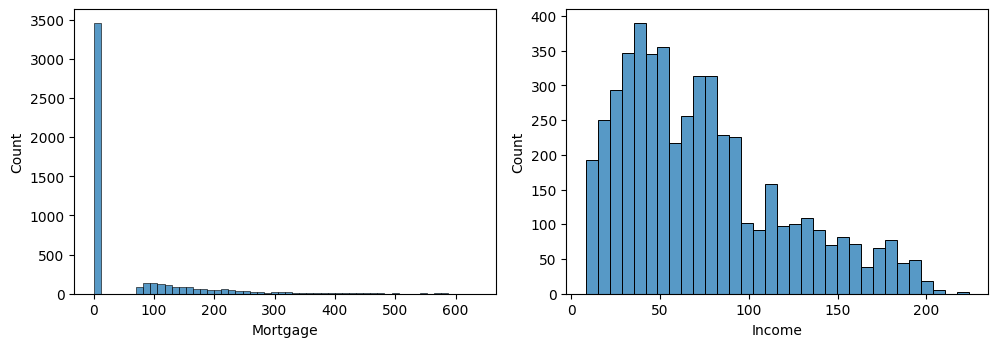

In [244]:
# defining the figure size
plt.figure(figsize=(15, 10))

# defining the list of numerical features to plot
num_features = ['Mortgage', 'Income']

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

CreditCard
0    70.6
1    29.4
Name: proportion, dtype: float64 



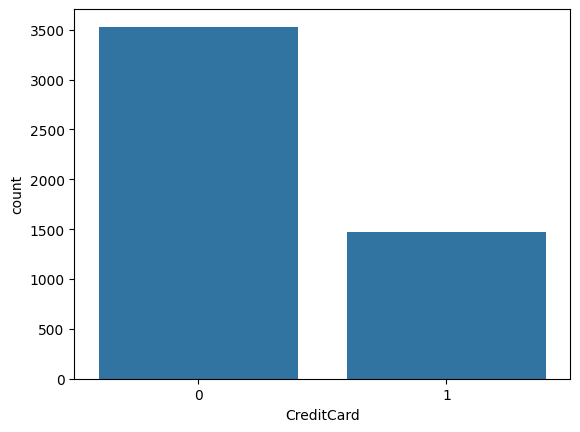

In [245]:
# checking the distribution of the categories in CreditCard
print(100*data['CreditCard'].value_counts(normalize=True), '\n')

# plotting the count plot for CreditCard
sns.countplot(data=data, x='CreditCard');

#### Observations
1. Distribution of Mortgage

- Highly right-skewed.

- Most customers have 0 mortgage.

- A smaller number have mortgages between 50–300.

- A few very large values (400–600) appear as outliers.


2. How many customers have credit cards?

- 0 (no credit card): 3,500 customers (approximately)

- 1 (has a credit card): 1,500 customers (approximately)

- So, over 70% do not have a credit card.


Observations on Income

- The income distribution is right-skewed.

- Most customers earn between 30k and 80k.

- The peak (mode) occurs around 40k–60k.

- There is a noticeable spread, with incomes ranging from below 20 up to over 200.

- Higher-income customers (above 120) are less frequent but still present.

- A long right tail indicates a small number of very high-income outliers.

### Bivariate Analysis

#### Correlation

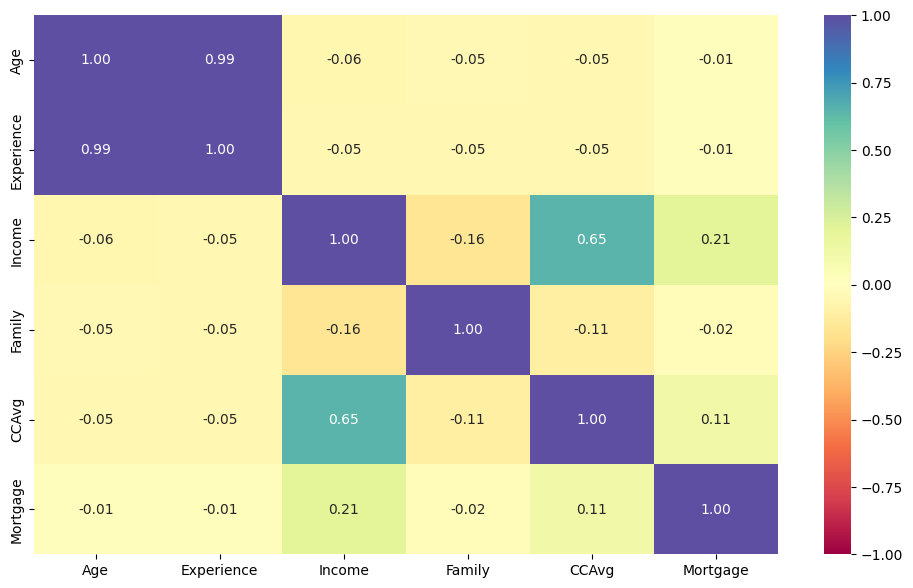

In [246]:
# defining the size of the plot
plt.figure(figsize=(12, 7))

# plotting the heatmap for correlation
sns.heatmap(
    data.corr(numeric_only= True),annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
);

##### Observation
The correlation heatmap shows that Age and Experience are almost perfectly correlated, indicating that older customers naturally have more years of work experience. There is also a strong positive correlation between Income and CCAvg, meaning higher-income customers tend to spend more on their credit cards. All other relationships in the heatmap show very weak or negligible correlations, suggesting that variables such as Family size and Mortgage amount do not strongly relate to the others. Overall, only Age–Experience and Income–CCAvg demonstrate meaningful patterns, while the rest of the attributes appear largely independent of each other.

#### Personal loan vs Education

In [247]:
# checking the distribution of the categories in Education and Personal_Loan
print(100*data['Education'].value_counts(normalize=True), '\n')
print(100*data['Personal_Loan'].value_counts(normalize=True), '\n')


Education
Undergraduate    41.92
Professional     30.02
Graduate         28.06
Name: proportion, dtype: float64 

Personal_Loan
0    90.4
1     9.6
Name: proportion, dtype: float64 



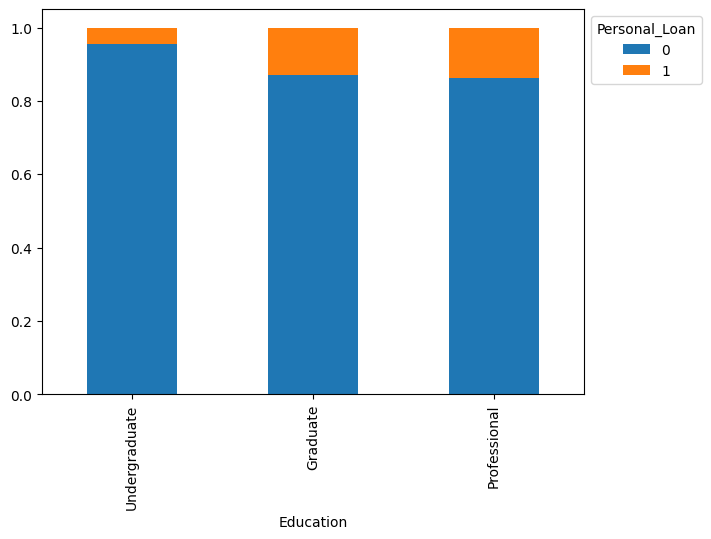

In [248]:

# creating a crosstab for Personal Loan vs Education
tab = pd.crosstab(
    data['Education'],
    data['Personal_Loan'],
    normalize='index'    # normalizing by dividing each row by its row total
).sort_values(by=0, ascending=False)    # sorting the resulting crosstab


# Plot the stacked bar chart
tab.plot(kind='bar', stacked=True, figsize=(7, 5))    # creating a stacked bar chart from the normalized crosstab
plt.xlabel('Education')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Personal_Loan');    # adding a legend for the 'Personal_Loan' column

##### Observations
- Customers with higher education levels show a greater interest in purchasing personal loans.

- Undergraduates have the lowest proportion of loan acceptance.

- Graduates have a noticeably higher acceptance rate.

- Professionals show a similar or slightly higher acceptance rate compared to graduates.

- Overall, the likelihood of taking a personal loan increases with education level, suggesting that more educated customers may have higher financial awareness or income, making them more open to loan products.

#### Personal Loan vs Age

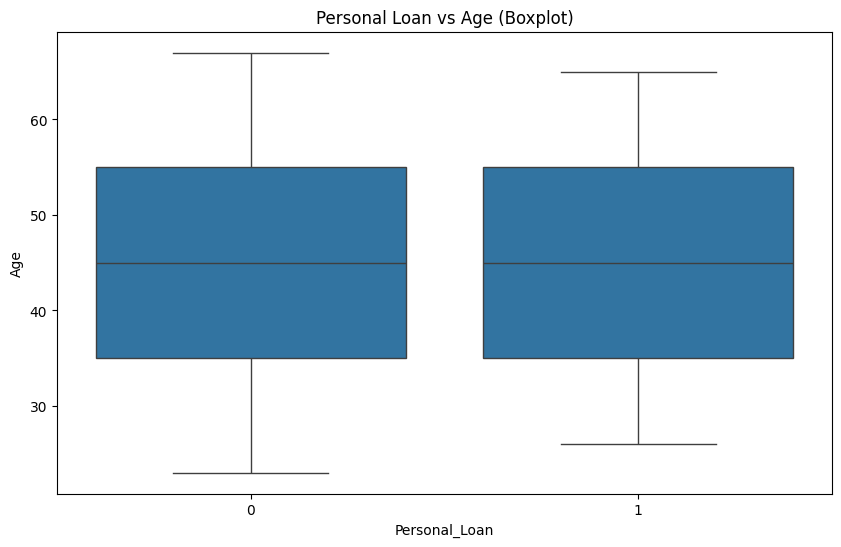

In [249]:
# Personal Loan vs Age (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Personal_Loan', y='Age')
plt.title('Personal Loan vs Age (Boxplot)')
plt.show()

##### Observation
- The age distributions for those with (1) and without (0) a personal loan are very similar.
- Both groups have nearly identical medians and IQRs.
- There is no strong age-based difference in personal loan status.

#### Personal Loan vs Income

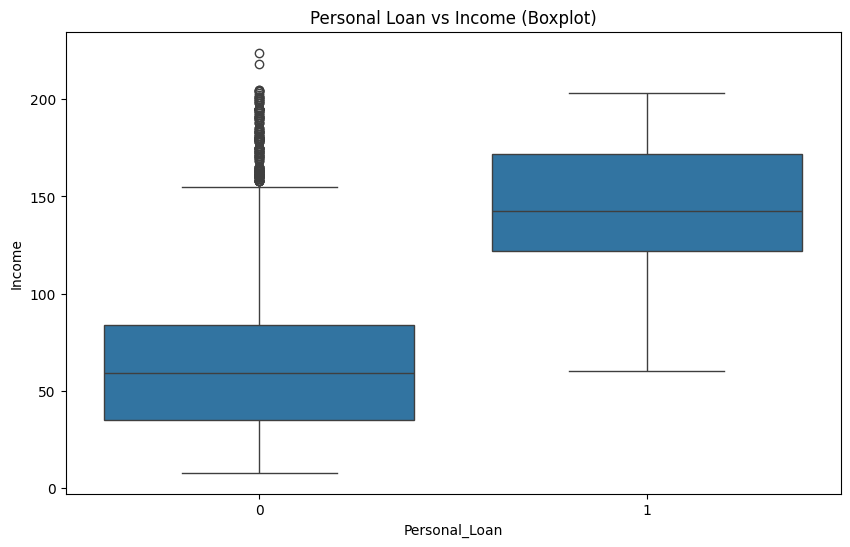

In [250]:
# Personal Loan vs Income (boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Personal_Loan', y='Income')
plt.title('Personal Loan vs Income (Boxplot)')
plt.show()

##### Observations
* Customers who **took a personal loan (1)** have **significantly higher incomes** than those who did not.
* The **median income** is much higher for the loan group, and their entire income distribution is shifted upward.
* Non-loan customers (0) show many **lower-income values** and more **high-income outliers**, but overall have much lower incomes.
* Overall: **Higher-income customers are far more likely to take a personal loan**.


## Data Pre-processing

### Data preparing for modelling

In [251]:
# dropping Experience as it is perfectty corretated with Age
X = data.drop( ["Personal_Loan", "Experience"], axis=1)
Y = data ["Personal_Loan"]

X = pd.get_dummies(X, columns=["ZIPCode", "Education"], drop_first=True)
X = X.astype(float)

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.30, random_state=1 )

In [252]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test. shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (3500, 17)
Shape of test set :  (1500, 17)
Percentage of classes in training set:
Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Percentage of classes in test set:
Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


## Model Building

### Model Evaluation Criterion

A model can make two types of mistakes:

1. Predicting that a customer **will take** a personal loan when they actually **won’t** — leading to wasted effort and resources.
2. Predicting that a customer **won’t take** a personal loan when they actually **would have** — resulting in a lost sales opportunity.

Among these, the more critical issue is **missing a potential customer** (a false negative). This happens when the model predicts “no loan,” but the customer was actually likely to accept one.

To reduce these false negatives, the bank should focus on **maximizing Recall**. A higher Recall means the model correctly identifies more of the customers who are genuinely likely to take the loan, thereby minimizing missed opportunities.


### Model Building

In [253]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):

  """
  Function to compute different metrics to check classification model performance

  model: classifier
  predictors: independent variables
  target: dependent variable
  """

  # predicting using the independent variables
  pred = model.predict(predictors)

  acc = accuracy_score(target, pred) # to compute Accuracy
  recall = recall_score(target, pred) # to compute Recall
  precision = precision_score(target, pred) # to compute Precision
  f1 = f1_score(target, pred) # to compute F1-score

  # creating a dataframe of metrics
  df_perf = pd.DataFrame(
  {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
  index=[0],
  )

  return df_perf

In [254]:
def confusion_matrix_sklearn(model, predictors, target):
  """
  To plot the confusion_matrix with percentages

  model: classifier
  predictors: independent variables
  target: dependent variable
  """

  y_pred = model.predict(predictors)
  cm = confusion_matrix(target, y_pred)
  labels = np.asarray([
    ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
    for item in cm.flatten()
  ]
  ).reshape(2, 2)

  plt.figure(figsize=(6, 4))
  sns.heatmap(cm, annot=labels, fmt="")
  plt.ylabel("True label")
  plt.xlabel("Predicted label")


#### Decision Tree

In [255]:
model0 = DecisionTreeClassifier(criterion="gini", random_state=1)
model0.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

#### Checking model performance on training set

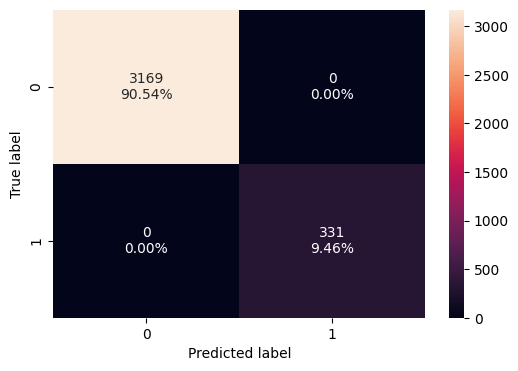

In [256]:
confusion_matrix_sklearn(model0, X_train, y_train)

In [257]:
decision_tree_perf_train = model_performance_classification_sklearn(model0, X_train, y_train)
decision_tree_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


- Model performed well on training data
- Metrics (Accuracy, Recall, Precision, F1) are all 1.0, indicating perfect performance.

- The model made no classification errors (no false positives or false negatives).

- Perfect scores may indicate:

  - A very small or overly simple dataset.

  - Data leakage between training and testing sets.

  - Overfitting if evaluated on training data instead of a separate test set.

#### Visualizing Decision Tree

In [258]:
feature_names = list(X_train.columns)
print(feature_names)

['Age', 'Income', 'Family', 'CCAvg', 'Mortgage', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard', 'ZIPCode_91', 'ZIPCode_92', 'ZIPCode_93', 'ZIPCode_94', 'ZIPCode_95', 'ZIPCode_96', 'Education_Professional', 'Education_Undergraduate']


In [ ]:
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
model0,
feature_names=feature_names,
filled=True,
fontsize=9,
node_ids=False,
class_names=None,
)

# below code will add arrows to the decision tree split if they are missing
for o in out:
  arrow = o.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor("black")
    arrow.set_linewidth(1)

plt.show()

In [ ]:
# Text report showing the rules of a decision tree

print(tree.export_text(model0, feature_names=feature_names, show_weights=True))

In [ ]:
print(pd.DataFrame(
model0. feature_importances_, columns=["Imp"], index=X_train.columns
).sort_values(by="Imp", ascending=False))

In [ ]:
importances = model0. feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##### **Observations**

* **Education_Undergraduate is the most influential feature**, contributing the highest relative importance to the model’s predictions.
* **Income is the second-most important factor**, strongly driving the model outcome.
* **Family size** also plays a meaningful role, ranking third in importance.
* **CCAvg (Credit Card Average Spending)**, **Age**, and **CD_Account** have **moderate influence**, suggesting they contribute but are not dominant.
* **Mortgage**, **Education_Professional**, and **ZIPCode_92** have **minimal influence**, indicating limited predictive value.
* Several features such as **ZIPCode_93, ZIPCode_94, ZIPCode_96, ZIPCode_91, ZIPCode_95, Online, CreditCard, and Securities_Account** appear to have **negligible or zero importance**, meaning the model does not rely on them.
* The dominance of only a few features (Education, Income, Family) suggests the model may be **highly sensitive to socioeconomic characteristics**.
* The sharp drop-off in importance after the first few features may indicate:

  * Possible **feature redundancy**
  * Some features may not be informative for this prediction task
  * Opportunity for **dimensionality reduction** without hurting performance


#### Checking model performance on test data

In [ ]:
confusion_matrix_sklearn(model0, X_test, y_test)

In [ ]:
decision_tree_perf_test = model_performance_classification_sklearn(model0, X_test, y_test)
decision_tree_perf_test

- The model performs very well overall, though recall is slightly lower than precision.

- This means the model is more conservative, favoring fewer false positives at the cost of missing some true positives.

- The gap between accuracy (very high) and recall (lower) may indicate:

- Class imbalance, where misclassifying positives affects recall more.

- The model may need adjusted thresholds or improved sensitivity if capturing positives is critical.

## Model Performance Improvement

### Pre-pruning

In [ ]:
# Define the parameters of the tree to iterate over
max_depth_values = np.arange(2, 7,2)
max_leaf_nodes_values = [50, 75, 150, 250]
min_samples_split_values = [10, 30, 50, 70]

# Initialize variables to store the best model and its performance
best_estimator = None
best_score_diff = float('inf')
best_test_score = 0.0

# Iterate over all combinations of the specified parameter values
for max_depth in max_depth_values:
  for max_leaf_nodes in max_leaf_nodes_values:
    for min_samples_split in min_samples_split_values:

      # Initialize the tree with the current set of parameters
      estimator = DecisionTreeClassifier(
      max_depth=max_depth,
      max_leaf_nodes=max_leaf_nodes,
      min_samples_split=min_samples_split,
      class_weight='balanced',
      random_state=42)

      # Fit the model to the training data
      estimator.fit(X_train, y_train)

      # Make predictions on the training and test sets
      y_train_pred = estimator.predict(X_train)
      y_test_pred = estimator.predict(X_test)

      # Calculate recall scores for training and test sets
      train_recall_score = recall_score(y_train, y_train_pred)
      test_recall_score = recall_score(y_test, y_test_pred)

      # Calculate the absolute difference between training and test recall scores
      score_diff = abs(train_recall_score - test_recall_score)

      # Update the best estimator and best score if the current one has a smaller score difference
      if (score_diff < best_score_diff) & (test_recall_score > best_test_score):
        best_score_diff = score_diff
        best_test_score = test_recall_score
        best_estimator = estimator


# creating an instance of the best model
model1 = best_estimator

# Print the best parameters
print("Best parameters found:")
print(f"Max depth: {best_estimator.max_depth}")
print(f"Max leaf nodes: {best_estimator.max_leaf_nodes}")
print(f"Min samples split: {best_estimator.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

#### Checking model performance on training set

In [ ]:
confusion_matrix_sklearn(model1, X_train, y_train)

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_sklearn(model1, X_train, y_train)
decision_tree_tune_perf_train

- The model is over-predicting the positive class, causing:
    - Many false positives
    - Inflated recall but severely depressed precision
- The combination of perfect recall but poor precision suggests:
    - Threshold may be too low for the positive class
    - Class imbalance may be influencing the classifier
    - Possible overfitting to positive signals
- Despite capturing all true positives, the large number of false alarms makes predictions unreliable for decision-making.

#### Visualizing Decision Tree

In [ ]:
feature_names = list(X_train.columns)
print(feature_names)

In [ ]:
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
model1,
feature_names=feature_names,
filled=True,
fontsize=9,
node_ids=False,
class_names=None,
)

# below code will add arrows to the decision tree split if they are missing
for o in out:
  arrow = o.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor("black")
    arrow.set_linewidth(1)

plt.show()

In [ ]:
# Text report showing the rules of a decision tree

print(tree.export_text(model1, feature_names=feature_names, show_weights=True))

In [ ]:
print(pd.DataFrame(
model1.feature_importances_, columns=["Imp"], index=X_train.columns
).sort_values(by="Imp", ascending=False))

In [ ]:
importances = model1.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##### **Observations**

The model is extremely sensitive to Income, suggesting:
  - The target variable may be highly correlated with income.
  - The model may be underfitting or not capturing more nuanced interactions.
  - Other features may not add meaningful variance or may be overshadowed.

The lack of contribution from many features could indicate:
  - Redundant or uninformative variables
  - Need for improved feature engineering
  - Potential for dimensionality reduction with no performance loss.


#### Checking model performance on test data

In [ ]:
confusion_matrix_sklearn(model1, X_test, y_test)

In [ ]:
decision_tree_tune_perf_test = model_performance_classification_sklearn(model1, X_test, y_test)
decision_tree_tune_perf_test

- Accuracy is about 0.779, indicating moderate overall performance.
- Recall is 1.0, meaning the model identifies all positive cases with no false negatives.
- Precision is about 0.31, showing a very high false-positive rate.
- F1-score is about 0.47, reflecting the imbalance between perfect recall and low precision.
- The model is heavily over-predicting the positive class.
- The high number of false positives makes predictions unreliable despite perfect recall.
- Metrics suggest possible class imbalance or a threshold set too low for positive predictions.
- The model prioritizes sensitivity at the cost of poor precision.

### Post-pruning

In [ ]:
# Calculating CCP Alpha Values
clf = DecisionTreeClassifier(random_state=1)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

In [ ]:
pd.DataFrame(path)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ccp_alphas[ :- 1], impurities[ :- 1], marker="o", drawstyle="steps-post")
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")
ax. set_title("Total Impurity vs effective alpha for training set")
plt.show()

In [ ]:
clfs = []
for ccp_alpha in ccp_alphas:
  clf = DecisionTreeClassifier(random_state=1, ccp_alpha=ccp_alpha)
  clf.fit(X_train, y_train)
  clfs.append(clf)

print(
  "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
  clfs[-1].tree_.node_count, ccp_alphas[-1]
  )
)

In [ ]:
clfs = clfs[ :- 1]
ccp_alphas = ccp_alphas[ :- 1]

node_counts = [clf.tree_.node_count for clf in clfs]
depth = [clf.tree_.max_depth for clf in clfs]
fig, ax = plt.subplots(2, 1, figsize=(10, 7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_xlabel("alpha")
ax[0].set_ylabel("number of nodes")
ax[0].set_title("Number of nodes vs alpha")
ax[1].plot(ccp_alphas, depth, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("alpha")
ax[1].set_ylabel("depth of tree")
ax[1].set_title("Depth vs alpha")
fig.tight_layout()

In [ ]:
# training data
recall_train = []
for clf in clfs:
  pred_train =clf.predict(X_train)
  values_train = recall_score(y_train, pred_train)
  recall_train.append(values_train)

# test data
recall_test = []
for clf in clfs:
  pred_test = clf.predict(X_test)
  values_test = recall_score(y_test, pred_test)
  recall_test.append(values_test)

In [ ]:
fig,ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("Recall")
ax.set_title("Recall vs alpha for training and testing sets")
ax.plot(ccp_alphas, recall_train, marker="o", label="train", drawstyle="steps-post")
ax.plot(ccp_alphas, recall_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [ ]:
# Best Model
index_best_model = np.argmax(recall_test)
best_model = clfs[index_best_model]
model2 = best_model
print(best_model)

- Post-pruning using ccp alpha returns the same model as the initial model (Tree with no pruning).
- As post pruning model is the same as the initial decision tree mode, the performance and feature importance will also be the same.

In [ ]:
estimator_2 = DecisionTreeClassifier(
ccp_alpha=0.0006209286209286216, class_weight={0: 0.15, 1: 0.85}, random_state=1
)
estimator_2.fit(X_train, y_train)

#### Checking model performance on training set

In [ ]:
confusion_matrix_sklearn(model2, X_train, y_train)

In [ ]:
decision_tree_tune_post_train = model_performance_classification_sklearn(model2, X_train, y_train)
decision_tree_tune_post_train

- The model performs consistently well across all metrics, with no major trade-offs.
- Only a small fraction of cases are misclassified.
- Results suggest the model is highly effective and generalizes well to the test data.

#### Visualizing Decision Tree

In [ ]:
feature_names = list(X_train.columns)
print(feature_names)

In [ ]:
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
estimator_2,
feature_names=feature_names,
filled=True,
fontsize=9,
node_ids=False,
class_names=None,
)

# below code will add arrows to the decision tree split if they are missing
for o in out:
  arrow = o.arrow_patch
  if arrow is not None:
    arrow.set_edgecolor("black")
    arrow.set_linewidth(1)

plt.show()

In [ ]:
# Text report showing the rules of a decision tree

print(tree.export_text(estimator_2, feature_names=feature_names, show_weights=True))

In [ ]:
print(pd.DataFrame(
estimator_2.feature_importances_, columns=["Imp"], index=X_train.columns
).sort_values(by="Imp", ascending=False))

In [ ]:
importances = estimator_2.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

##### **Observations**

- Income is the most important feature, contributing the highest relative importance by a large margin.
- Family size is the second most important feature, but much less influential than Income.
- Education_Undergraduate ranks third in importance, slightly behind Family.
- CCAvg (average credit card spending) has a moderate but noticeably lower impact.
-Age, CD_Account, Mortgage, and Securities_Account have small but non-negligible importance.
- Many features, including several ZIPCode variables, Online, CreditCard, and Education_Professional, have near-zero importance, indicating they contribute very little to the model's predictions.
- The model relies heavily on financial and demographic features like Income, Family, and Education rather than location or product ownership.
- This pattern suggests potential to focus on key socioeconomic features for efficient modeling or feature selection.

#### Checking model performance on test data

In [ ]:
confusion_matrix_sklearn(model2, X_test, y_test)

In [ ]:
decision_tree_tune_post_test = model_performance_classification_sklearn(model2, X_test, y_test)
decision_tree_tune_post_test

- The model is both accurate and reliable at identifying positive cases.
- Slightly higher precision than recall suggests the model is a bit more conservative in predicting positives but still maintains good sensitivity.

## Model Performance Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
[decision_tree_perf_train.T, decision_tree_tune_perf_train.T, decision_tree_tune_post_train.T], axis=1,)

models_train_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Training performance comparison:")
models_train_comp_df


In [ ]:
# test performance comparison

models_test_comp_df = pd.concat(
[decision_tree_perf_test.T, decision_tree_tune_perf_test.T, decision_tree_tune_post_test.T], axis=1,)

models_test_comp_df.columns = ["Decision Tree (sklearn default)", "Decision Tree (Pre-Pruning)", "Decision Tree (Post-Pruning)"]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Decision Tree (sklearn default),Decision Tree (Pre-Pruning),Decision Tree (Post-Pruning)
Accuracy,0.981333,0.779333,0.984000
Recall,0.899329,1.000000,0.906040
Precision,0.911565,0.310417,0.931034
F1,0.905405,0.473768,0.918367


##### Conclusion

- The default Decision Tree overfits the training data and loses some sensitivity on test data.

- The pre-pruned model sacrifices precision heavily to achieve perfect recall but underfits overall, resulting in poor balance.

- The post-pruned Decision Tree achieves the best trade-off between bias and variance, demonstrating excellent performance and generalization on both training and test datasets.



## Actionable Insights and Business Recommendations



### Actionable Insights
* Income is the most significant factor influencing personal loan purchases.
* Education level, especially undergraduate status, strongly affects purchase likelihood.
* Family size and average credit card spending also impact purchasing behavior.
* High-income customers with undergraduate education and larger families are most likely to buy loans.
* The post-pruned Decision Tree model is the most reliable for predicting loan purchases.


### Business Recommendations

* Target marketing campaigns toward high-income customers with undergraduate education and larger families.
* Use credit card spending data to tailor personalized offers and promotions.
* Highlight loan benefits that appeal to financially stable and educated customers.
* Allocate sales and marketing resources to these high-potential segments for better ROI.
* Create educational content for less likely customers to increase future conversions.
* Update and monitor the predictive model regularly to maintain and improve accuracy.


___